# EDA - Análise Exploratória dos Dados

## Objetivo

Nessa análise exploratória, queremos entender a estrutura, qualidade e distribuição das variáveis do dataset de customer support tickets.
A análise será utilizada para identificar padrões relevantes nos dados e depois formular hipoteses sobre as intenções dos usuários.

## Baixando dataset

In [1]:
!pip install kagglehub

### Load libs

In [2]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt

### Load csv

In [3]:
dataset_folder = kagglehub.dataset_download("suraj520/customer-support-ticket-dataset")
dataset_file_name = "customer_support_tickets.csv"
dataset_file_path = dataset_folder + "/" + dataset_file_name

### Load dataframe

In [4]:
df = pd.read_csv(dataset_file_path)

### Check load

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

## a. Compreensão do problema e do dataset

Esse dataset parece ser de registros de tickets de suporte abertos em diferentes canais, ele contém informações de quem abriu o ticket, o canal de comunicação, o produto e dados relacionado a resolução do problema.

## b. Inspeção inicial

### Coletando informações iniciais do dataset

In [6]:
print("Informacoes basicas")
shape = df.shape
print("Quantidade de registros: ", shape[0])
print("Quantidade de variaveis: ", shape[1])
print("Variaveis:")
for column in df.columns: print("- " + str(column))

Informacoes basicas
Quantidade de registros:  8469
Quantidade de variaveis:  17
Variaveis:
- Ticket ID
- Customer Name
- Customer Email
- Customer Age
- Customer Gender
- Product Purchased
- Date of Purchase
- Ticket Type
- Ticket Subject
- Ticket Description
- Ticket Status
- Resolution
- Ticket Priority
- Ticket Channel
- First Response Time
- Time to Resolution
- Customer Satisfaction Rating


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [8]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [9]:
df.describe(include="all")

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
count,8469.000000,8469,8469,8469.000000,8469,8469,8469,8469,8469,8469,8469,2769,8469,8469,5650,2769,2769.000000
unique,NaN,8028,8320,NaN,3,42,730,5,16,8077,3,2769,4,4,5470,2728,NaN
top,NaN,Michael Garcia,bsmith@example.com,NaN,Male,Canon EOS,2020-10-21,Refund request,Refund request,I'm having an issue with the {product_purchase...,Pending Customer Response,Case maybe show recently my computer follow.,Medium,Email,2023-06-01 15:21:42,2023-06-01 17:14:42,NaN
freq,NaN,5,4,NaN,2896,240,24,1752,576,25,2881,1,2192,2143,3,3,NaN
mean,4235.000000,NaN,NaN,44.026804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.991333
std,2444.934048,NaN,NaN,15.296112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.407016
min,1.000000,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
25%,2118.000000,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000
50%,4235.000000,NaN,NaN,44.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000
75%,6352.000000,NaN,NaN,57.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000


### Tipo de variaveis encontradas

- Identificadores:
    - Ticket ID
- Numericas:
    - Customer Age
    - Customer Satisfaction Rating
- Categoricas:
    - Customer Gender
    - Ticket Subject
    - Ticket Status
    - Ticket Priority
    - Ticket Channel
- Datas
    - Date of Purchase
    - First Response Time
    - Time to Resolution
- Textos:
    - Product Purchased
    - Customer Email
    - Customer Name
    - Ticket Description
    - Resolution

## c. Verificação da qualidade dos dados

In [10]:
print("Quantidade de nulos por variavel")
df.isna().sum()

Quantidade de nulos por variavel


Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [11]:
print("Porcentagem de nulos por variavel")
(df.isna().mean() * 100).sort_values(ascending=False)

Porcentagem de nulos por variavel


Customer Satisfaction Rating    67.304286
Time to Resolution              67.304286
Resolution                      67.304286
First Response Time             33.286102
Ticket Description               0.000000
Ticket Channel                   0.000000
Ticket Priority                  0.000000
Ticket Status                    0.000000
Ticket ID                        0.000000
Customer Name                    0.000000
Ticket Type                      0.000000
Date of Purchase                 0.000000
Product Purchased                0.000000
Customer Gender                  0.000000
Customer Age                     0.000000
Customer Email                   0.000000
Ticket Subject                   0.000000
dtype: float64

In [12]:
print("Quantidade de tickets duplicados: " + str(df["Ticket ID"].duplicated().sum()))

Quantidade de tickets duplicados: 0


In [13]:
categorical_variables = [
    "Customer Gender",
    "Ticket Subject",
    "Ticket Status",
    "Ticket Priority",
    "Ticket Channel",
]

print("Variaveis categoricas:")
for variable in categorical_variables:
    print(f"  Valores unicos de \"{variable}\":")
    for unique_label in df[variable].unique():
        count_unique = (df[variable] == unique_label).sum()
        print(f"    \"{unique_label}\" - {count_unique}")    

Variaveis categoricas:
  Valores unicos de "Customer Gender":
    "Other" - 2686
    "Female" - 2887
    "Male" - 2896
  Valores unicos de "Ticket Subject":
    "Product setup" - 529
    "Peripheral compatibility" - 496
    "Network problem" - 539
    "Account access" - 509
    "Data loss" - 491
    "Payment issue" - 526
    "Refund request" - 576
    "Battery life" - 542
    "Installation support" - 530
    "Software bug" - 574
    "Hardware issue" - 547
    "Product recommendation" - 517
    "Delivery problem" - 561
    "Display issue" - 478
    "Cancellation request" - 487
    "Product compatibility" - 567
  Valores unicos de "Ticket Status":
    "Pending Customer Response" - 2881
    "Closed" - 2769
    "Open" - 2819
  Valores unicos de "Ticket Priority":
    "Critical" - 2129
    "Low" - 2063
    "High" - 2085
    "Medium" - 2192
  Valores unicos de "Ticket Channel":
    "Social media" - 2121
    "Chat" - 2073
    "Email" - 2143
    "Phone" - 2132


In [14]:
numerical_variables = [
    "Customer Age",
    "Customer Satisfaction Rating"
]

print("Variaveis numericas")
for variable in numerical_variables:
    print(f"Variavel: \"{variable}\"")
    print(df[variable].describe())
    print("\n")

Variaveis numericas
Variavel: "Customer Age"
count    8469.000000
mean       44.026804
std        15.296112
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: Customer Age, dtype: float64


Variavel: "Customer Satisfaction Rating"
count    2769.000000
mean        2.991333
std         1.407016
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Customer Satisfaction Rating, dtype: float64




In [15]:
date_variables = [
    "Date of Purchase",
    "First Response Time",
    "Time to Resolution"
]


print("As variaveis de data estão com tipagem correta?")
for variable in date_variables:
    check_message = "❌"
    if pd.api.types.is_datetime64_any_dtype(df[variable]):
        check_message = "✅"
    print(f"\"{variable}\": {check_message}")
    

As variaveis de data estão com tipagem correta?
"Date of Purchase": ❌
"First Response Time": ❌
"Time to Resolution": ❌


### Observação final

Os dados parecem ter uma qualidade boa, as analises até aqui não encontraram nada foram do normal.

## d. Preparação dos dados

### Corrigindo campo de datas com tipagem incorreta

Os campos de data do dataframe estavam com a tipagem `Object`, o que poderia impactar nossas analises.

In [16]:
for variable in date_variables:
    df[variable] = df[variable].apply(pd.to_datetime)

print(df[date_variables].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date of Purchase     8469 non-null   datetime64[ns]
 1   First Response Time  5650 non-null   datetime64[ns]
 2   Time to Resolution   2769 non-null   datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 198.6 KB
None


## e. Análise Univariada

### Categoricas

In [17]:
categorical_variables_per_value_counts = {}

for variable in categorical_variables:
    value_counts = df[variable].value_counts()
    categorical_variables_per_value_counts[variable] = value_counts.to_dict()
    print(value_counts)
    print()

Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64

Ticket Subject
Refund request              576
Software bug                574
Product compatibility       567
Delivery problem            561
Hardware issue              547
Battery life                542
Network problem             539
Installation support        530
Product setup               529
Payment issue               526
Product recommendation      517
Account access              509
Peripheral compatibility    496
Data loss                   491
Cancellation request        487
Display issue               478
Name: count, dtype: int64

Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name:

In [18]:
for variable in categorical_variables:
    print(df[variable].value_counts(normalize=True) * 100)
    print()

Customer Gender
Male      34.195301
Female    34.089031
Other     31.715669
Name: proportion, dtype: float64

Ticket Subject
Refund request              6.801275
Software bug                6.777660
Product compatibility       6.695005
Delivery problem            6.624159
Hardware issue              6.458850
Battery life                6.399811
Network problem             6.364388
Installation support        6.258118
Product setup               6.246310
Payment issue               6.210887
Product recommendation      6.104617
Account access              6.010155
Peripheral compatibility    5.856654
Data loss                   5.797615
Cancellation request        5.750384
Display issue               5.644114
Name: proportion, dtype: float64

Ticket Status
Pending Customer Response    34.018184
Open                         33.286102
Closed                       32.695714
Name: proportion, dtype: float64

Ticket Priority
Medium      25.882631
Critical    25.138741
High        24.619199
Lo

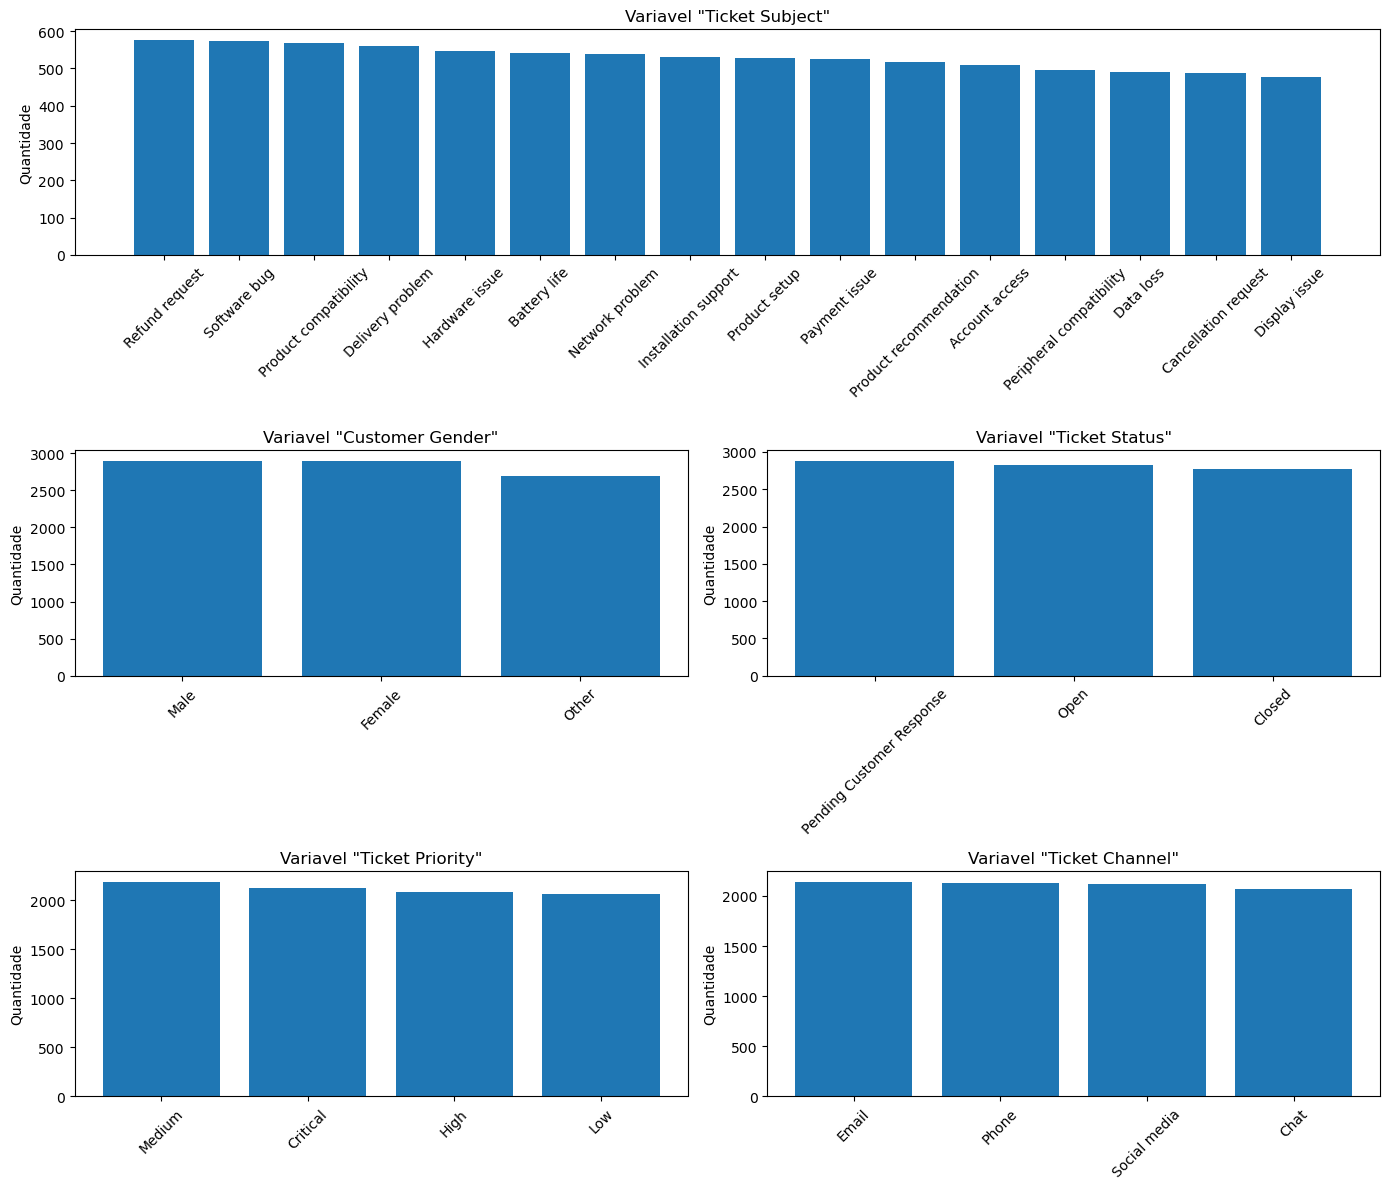

In [19]:
fig = plt.figure(figsize=(14, 12))
grid = fig.add_gridspec(3, 2)

ax = fig.add_subplot(grid[0, :])
counts = df["Ticket Subject"].value_counts()
ax.bar(counts.index, counts.values)
ax.set_title("Variavel \"Ticket Subject\"")
ax.set_ylabel("Quantidade")
ax.tick_params(axis="x", rotation=45)

for ax, variable in zip(
    [fig.add_subplot(grid[1, 0]),
     fig.add_subplot(grid[1, 1]),
     fig.add_subplot(grid[2, 0]),
     fig.add_subplot(grid[2, 1])],
    ["Customer Gender", "Ticket Status", "Ticket Priority", "Ticket Channel"]
):
    counts = df[variable].value_counts()

    ax.bar(counts.index, counts.values)
    ax.set_title(f"Variavel \"{variable}\"")
    ax.set_ylabel("Quantidade")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Numericas

In [20]:
print(numerical_variables)

['Customer Age', 'Customer Satisfaction Rating']


In [32]:
print(df[numerical_variables].describe())

       Customer Age  Customer Satisfaction Rating
count   8469.000000                   2769.000000
mean      44.026804                      2.991333
std       15.296112                      1.407016
min       18.000000                      1.000000
25%       31.000000                      2.000000
50%       44.000000                      3.000000
75%       57.000000                      4.000000
max       70.000000                      5.000000


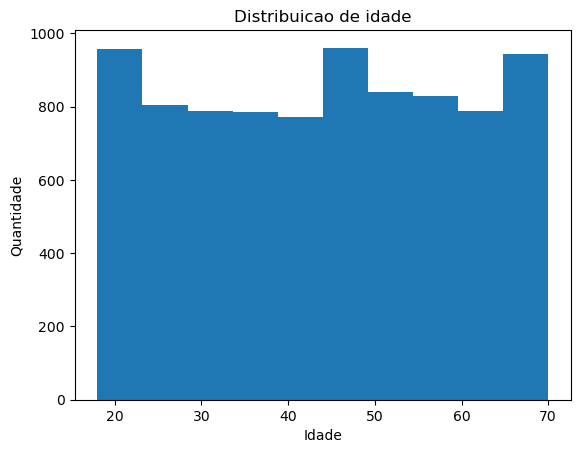

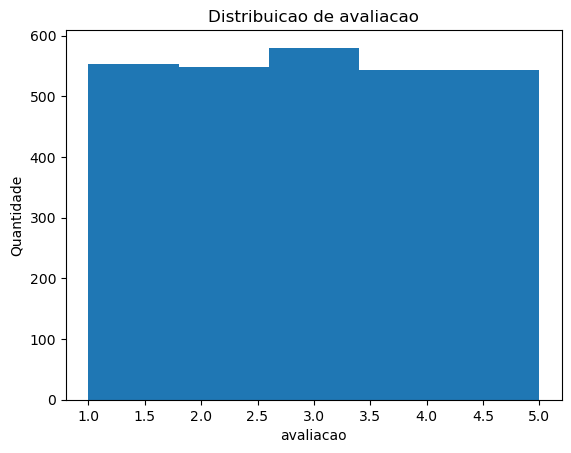

In [38]:
df['Customer Age'].plot(kind="hist", bins=10)
plt.title("Distribuicao de idade")
plt.xlabel("Idade")
plt.ylabel("Quantidade")
plt.show()

df['Customer Satisfaction Rating'].plot(kind="hist", bins=5)
plt.title("Distribuicao de avaliacao")
plt.xlabel("avaliacao")
plt.ylabel("Quantidade")
plt.show()

### Temporais

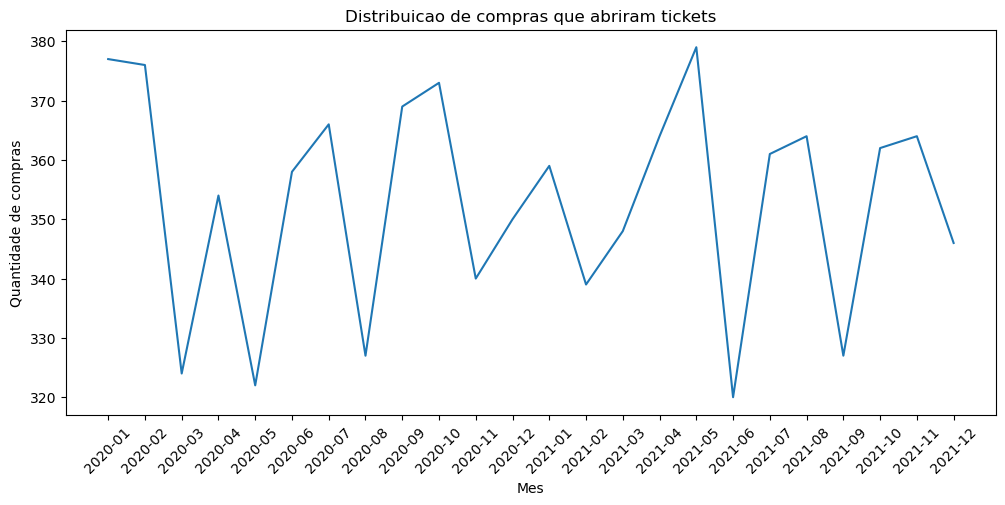

In [31]:
purchase_by_month = (
    df["Date of Purchase"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

purchase_by_month.index = purchase_by_month.index.astype(str)

plt.figure(figsize=(12, 5))
plt.plot(purchase_by_month.index, purchase_by_month.values)
plt.title("Distribuicao de compras que abriram tickets")
plt.xlabel("Mes")
plt.ylabel("Quantidade de compras")
plt.xticks(rotation=45)
plt.show()

### Interpretação da análise univariada

#### Variáveis categóricas

As variáveis categóricas apresentam uma distribuição relativamente equilibrada entre suas categorias. `Ticket Status`, `Ticket Priority` e `Ticket Channel` também apresentam distribuições que permitem observar a participação de cada categoria sem uma concentração extrema em um único grupo.

#### Variáveis numéricas

`Customer Age`: Apresenta uma distribuição dos registros ao longo das diferentes faixas etárias, iniciando aos 18 anos e permitindo ver o perfil de idade dos clientes presentes no dataset.

`Customer Satisfaction Rating`: A distribuição permite ver como as avaliações estão concentradas entre os diferentes níveis de satisfação.

#### Variáveis temporais

`Date of Purchase`: A distribuição ao longo dos meses analisados não uma concentração extrema em um único período.

`First Response Time` e `Time to Resolution`: A análise dos valores ausentes mostrou que `Time to Resolution` está preenchido para tickets encerrados e ausente para tickets que ainda estão abertos ou aguardando resposta do cliente, mas existem datas para a primeira resposta que estão após a data de resolução, então o entendimento desse campo ficou confuso.